# Template 05: Model Training

**Purpose:** Train XGBoost model and generate predictions

**Inputs:**
- data/04_train.parquet
- data/04_test.parquet

**Outputs:**
- models/xgb_model.json
- results/05_metrics.yaml
- results/05_predictions.parquet

In [1]:
config_path = "config/car_coll/v1"

In [2]:
# Parameters
config_path = "config/car_coll/v1"


In [3]:
import matplotlib
matplotlib.use('Agg')  # Non-interactive backend for papermill

import pandas as pd
import numpy as np
import xgboost as xgb
import yaml
import os
import sys
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error

sys.path.insert(0, str(Path.cwd() / 'lib'))
from utils import setup_notebook_environment

print("########################################")
print("# STAGE 05: MODEL TRAINING")
print("########################################")

project_root = setup_notebook_environment()

########################################
# STAGE 05: MODEL TRAINING
########################################


In [4]:
print(f"Python: {sys.version}")
print(f"XGBoost: {xgb.__version__}")


Python: 3.11.15 (main, Jun 11 2026, 15:14:57) [Clang 20.1.8 ]
XGBoost: 3.1.1


In [5]:
config_file = f"{config_path}/config.yaml"
with open(config_file, 'r') as f:
    cfg = yaml.safe_load(f)

output_base = cfg['paths']['output_base']
target = cfg['experiment']['target']
exposure = cfg['experiment']['exposure']

In [6]:
# Load ENCODED train/test data from Stage 04c
train_encoded = pd.read_parquet(f"{output_base}/data/04c_train_encoded.parquet")
test_encoded = pd.read_parquet(f"{output_base}/data/04c_test_encoded.parquet")

# Load original data for target/exposure
train_orig = pd.read_parquet(f"{output_base}/data/04_train.parquet")
test_orig = pd.read_parquet(f"{output_base}/data/04_test.parquet")

print(f"\n* Train encoded: {train_encoded.shape}")
print(f"* Test encoded: {test_encoded.shape}")


* Train encoded: (3757142, 197)
* Test encoded: (3750266, 197)


In [7]:
# Use ALL encoded features (encoding already applied in 04c)
X_train = train_encoded
y_train = train_orig[target]
X_test = test_encoded
y_test = test_orig[target]

print(f"\n* Features: {X_train.shape[1]} encoded features")


* Features: 197 encoded features


In [8]:
# Train XGBoost model
print(f"\n* Training XGBoost...")

xgb_params = cfg['xgboost'].copy()
n_estimators = xgb_params.pop('n_estimators')

# Construct full eval_metric for tweedie if needed
if 'eval_metric' in xgb_params and 'tweedie' in xgb_params['eval_metric']:
    if '@' not in xgb_params['eval_metric']:
        variance_power = xgb_params['tweedie_variance_power']
        xgb_params['eval_metric'] = f"{xgb_params['eval_metric']}@{variance_power}"

model = xgb.XGBRegressor(n_estimators=n_estimators, **xgb_params)
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100
)

print(f"\n* Model trained")
print(f"* Best iteration: {model.best_iteration}")


* Training XGBoost...


[0]	validation_0-tweedie-nloglik@1.5:58.88187	validation_1-tweedie-nloglik@1.5:61.08594


[100]	validation_0-tweedie-nloglik@1.5:52.31963	validation_1-tweedie-nloglik@1.5:55.09494


[200]	validation_0-tweedie-nloglik@1.5:51.49469	validation_1-tweedie-nloglik@1.5:54.85416


[300]	validation_0-tweedie-nloglik@1.5:50.99615	validation_1-tweedie-nloglik@1.5:54.78685


[385]	validation_0-tweedie-nloglik@1.5:50.63086	validation_1-tweedie-nloglik@1.5:54.78281



* Model trained
* Best iteration: 335


In [9]:
# Save training history
results = model.evals_result()
metric_base = cfg['xgboost']['eval_metric']

# Construct full metric name for tweedie if needed
if 'tweedie' in metric_base and '@' not in metric_base:
    variance_power = cfg['xgboost']['tweedie_variance_power']
    metric = f"{metric_base}@{variance_power}"
else:
    metric = metric_base

# Use exact metric from results
result_key = list(results['validation_0'].keys())[0]

history_df = pd.DataFrame({
    'iteration': range(len(results['validation_0'][result_key])),
    f'train_{metric}': results['validation_0'][result_key],
    f'test_{metric}': results['validation_1'][result_key]
})

history_file = f"{output_base}/results/05_training_history.parquet"
history_df.to_parquet(history_file, index=False)
print(f"\n* Training history saved: {history_file}")
print(f"  Total iterations: {len(history_df)}")
print(f"  Metric: {metric}")
print(f"  Final train {metric}: {history_df[f'train_{metric}'].iloc[-1]:.4f}")
print(f"  Final test {metric}: {history_df[f'test_{metric}'].iloc[-1]:.4f}")


* Training history saved: output/car_coll/v1/results/05_training_history.parquet
  Total iterations: 386
  Metric: tweedie-nloglik@1.5
  Final train tweedie-nloglik@1.5: 50.6309
  Final test tweedie-nloglik@1.5: 54.7828



* Learning curve saved: output/car_coll/v1/plots/05_learning_curve.png


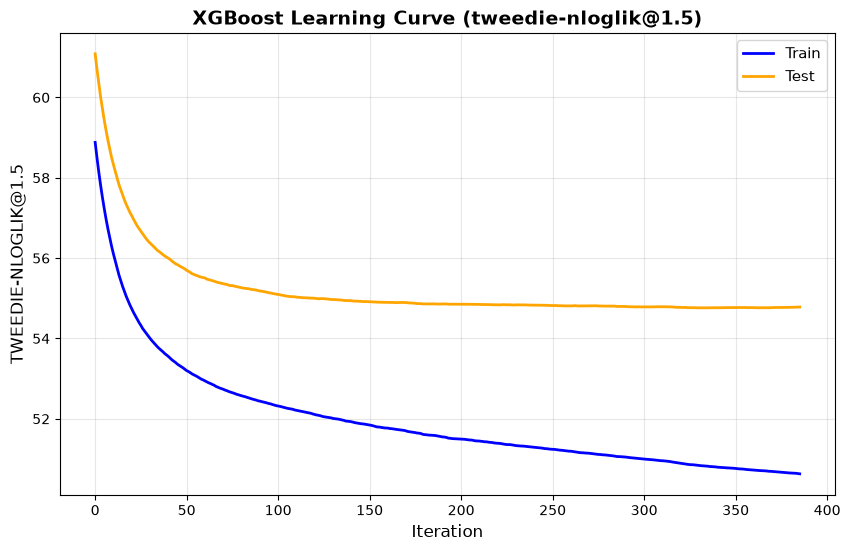

In [10]:
# Plot learning curve
from utils import plot_learning_curve
from IPython.display import Image, display

plot_path = plot_learning_curve(history_df, f"{output_base}/plots/05_learning_curve.png", metric=metric)
print(f"\n* Learning curve saved: {plot_path}")

# Display inline
display(Image(filename=plot_path))

In [11]:
# Predictions
train_orig['pred'] = model.predict(X_train)
test_orig['pred'] = model.predict(X_test)

# Metrics
train_mae = mean_absolute_error(y_train, train_orig['pred'])
test_mae = mean_absolute_error(y_test, test_orig['pred'])
train_rmse = np.sqrt(mean_squared_error(y_train, train_orig['pred']))
test_rmse = np.sqrt(mean_squared_error(y_test, test_orig['pred']))

print(f"\n* Metrics:")
print(f"  Train MAE: {train_mae:.4f}")
print(f"  Test MAE: {test_mae:.4f}")
print(f"  Train RMSE: {train_rmse:.4f}")
print(f"  Test RMSE: {test_rmse:.4f}")


* Metrics:
  Train MAE: 411.4935
  Test MAE: 427.3636
  Train RMSE: 8335.8059
  Test RMSE: 8840.6932


In [12]:
# Save model
model_file = f"{output_base}/models/xgb_model.json"
os.makedirs(f"{output_base}/models", exist_ok=True)
model.get_booster().save_model(model_file)
print(f"\n* Model saved: {model_file}")


* Model saved: output/car_coll/v1/models/xgb_model.json


In [13]:
# Save metrics
metrics = {
    'train_mae': float(train_mae),
    'test_mae': float(test_mae),
    'train_rmse': float(train_rmse),
    'test_rmse': float(test_rmse),
    'n_features': X_train.shape[1],
    'train_size': len(train_orig),
    'test_size': len(test_orig)
}

metrics_file = f"{output_base}/results/05_metrics.yaml"
with open(metrics_file, 'w') as f:
    yaml.dump(metrics, f)

print(f"* Metrics saved: {metrics_file}")

* Metrics saved: output/car_coll/v1/results/05_metrics.yaml


In [14]:
# Save predictions separately for train and test
# Train predictions
train_pred = train_orig[[target, exposure, 'pred']].copy()
train_pred.columns = ['actual', 'exposure', 'pred']

# Validate predictions output
required_cols = ['actual', 'exposure', 'pred']
missing = [c for c in required_cols if c not in train_pred.columns]
if missing:
    raise ValueError(f"[Stage 05] Missing prediction columns: {missing}")

train_pred_file = f"{output_base}/results/05_predictions_train.parquet"
train_pred.to_parquet(train_pred_file)

# Test predictions
test_pred = test_orig[[target, exposure, 'pred']].copy()
test_pred.columns = ['actual', 'exposure', 'pred']
test_pred_file = f"{output_base}/results/05_predictions_test.parquet"
test_pred.to_parquet(test_pred_file)

print(f"* Train predictions saved: {train_pred_file}")
print(f"* Test predictions saved: {test_pred_file}")
print(f"[Stage 05 Output] ✓ Prediction columns validated: {', '.join(required_cols)}")

* Train predictions saved: output/car_coll/v1/results/05_predictions_train.parquet
* Test predictions saved: output/car_coll/v1/results/05_predictions_test.parquet
[Stage 05 Output] ✓ Prediction columns validated: actual, exposure, pred


## Lift Charts

In [15]:
# Prepare data for lift charts
# Get exposure column from config, or use fallback logic
exposure_col = cfg['experiment'].get('exposure', None)

if exposure_col and exposure_col in train_orig.columns:
    weight_col = exposure_col
    print(f"\n* Using '{exposure_col}' from config as weight column")
elif 'ee' in train_orig.columns:
    weight_col = 'ee'
    print(f"\n* Using 'ee' (earned exposure) as weight column")
elif 'ee_imps' in train_orig.columns:
    weight_col = 'ee_imps'
    print(f"\n* Using 'ee_imps' (earned exposure imputed) as weight column")
else:
    train_orig['weight'] = 1  # Equal weight per record
    test_orig['weight'] = 1
    weight_col = 'weight'
    print(f"\n* WARNING: No exposure column found, using equal weighting (weight=1)")
    if exposure_col:
        print(f"  Config specifies '{exposure_col}' but it's not in the data!")

# Create incurred/denom columns for lift chart
# Use exposure as denominator if available
if weight_col in train_orig.columns and weight_col != 'weight':
    train_orig['incurred_act'] = train_orig[target]
    train_orig['incurred_pred'] = train_orig['pred']
    train_orig['denom'] = train_orig[weight_col]  # Use exposure as denominator
    
    test_orig['incurred_act'] = test_orig[target]
    test_orig['incurred_pred'] = test_orig['pred']
    test_orig['denom'] = test_orig[weight_col]
else:
    train_orig['incurred_act'] = train_orig[target]
    train_orig['incurred_pred'] = train_orig['pred']
    train_orig['denom'] = 1  # Equal weight
    
    test_orig['incurred_act'] = test_orig[target]
    test_orig['incurred_pred'] = test_orig['pred']
    test_orig['denom'] = 1

print(f"* Prepared data for lift charts (weight_col='{weight_col}')")


* Using 'ee_coll_imps' from config as weight column
* Prepared data for lift charts (weight_col='ee_coll_imps')


In [16]:
# Load optimized lift chart function
import matplotlib.pyplot as plt
from lift_chart_fast import create_lift_chart

print("* Optimized lift chart function loaded")

* Optimized lift chart function loaded


In [17]:
print("\n* Generating train lift chart...")



* Generating train lift chart...


In [18]:
fig_train_orig, table_train = create_lift_chart(train_orig, weight_col, bins=10, title="Train Lift Chart")

  [STEP 1] Creating column list...
  [STEP 1] Done in 0.000s
  [STEP 2] Extracting 5 columns from 3,757,142 rows...
  [STEP 2] Done in 0.023s
  [STEP 3a] Sorting by prediction (this may take 1-2 min for 2.7M rows)...


  [STEP 3a] sort_values done in 0.4s
  [STEP 3b] Resetting index...
  [STEP 3b] Done in 0.000s
  [STEP 4] Calculating cumulative weight...
  [STEP 4] Done in 0.019s
  [STEP 5] Aggregating by decile...
  [STEP 5] Done in 0.136s
  Creating plot...
  Plot created in 0.0s
  TOTAL TIME: 0.5s


  Saved: output/car_coll/v1/results/05_lift_chart_train.png


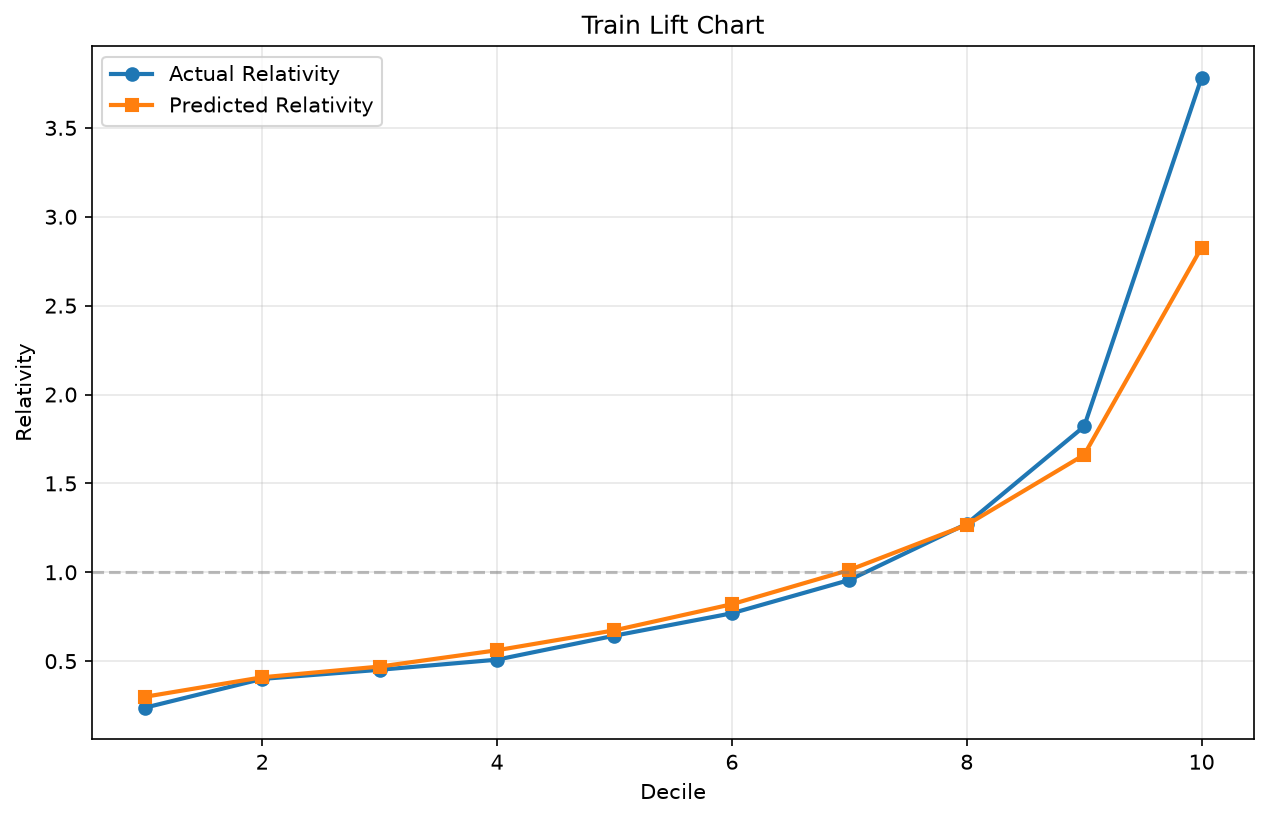


Train decile table:
   decile          act         pred   act_rel  pred_rel
0       1   104.255277   131.204358  0.237901  0.299397
1       2   175.360806   179.348283  0.400158  0.409257
2       3   197.827170   205.767963  0.451424  0.469544
3       4   222.765420   246.002879  0.508331  0.561356
4       5   281.884358   295.156014  0.643235  0.673520
5       6   337.136130   359.492784  0.769314  0.820330
6       7   419.098564   443.792612  0.956345  1.012695
7       8   557.716022   555.013998  1.272658  1.266492
8       9   797.776392   727.735357  1.820454  1.660627
9      10  1657.398890  1238.777327  3.782035  2.826779


In [19]:
# Train lift chart


train_chart_file = f"{output_base}/results/05_lift_chart_train.png"
fig_train_orig.savefig(train_chart_file, dpi=150, bbox_inches='tight')
plt.close(fig_train_orig)

print(f"  Saved: {train_chart_file}")

# Display inline in notebook
from IPython.display import Image, display
display(Image(train_chart_file))

print("\nTrain decile table:")
print(table_train[['decile', 'act', 'pred', 'act_rel', 'pred_rel']])


* Generating test lift chart...
  [STEP 1] Creating column list...
  [STEP 1] Done in 0.000s
  [STEP 2] Extracting 5 columns from 3,750,266 rows...
  [STEP 2] Done in 0.019s
  [STEP 3a] Sorting by prediction (this may take 1-2 min for 2.7M rows)...


  [STEP 3a] sort_values done in 0.4s
  [STEP 3b] Resetting index...
  [STEP 3b] Done in 0.000s
  [STEP 4] Calculating cumulative weight...
  [STEP 4] Done in 0.018s
  [STEP 5] Aggregating by decile...
  [STEP 5] Done in 0.135s
  Creating plot...
  Plot created in 0.0s
  TOTAL TIME: 0.5s


  Saved: output/car_coll/v1/results/05_lift_chart_test.png


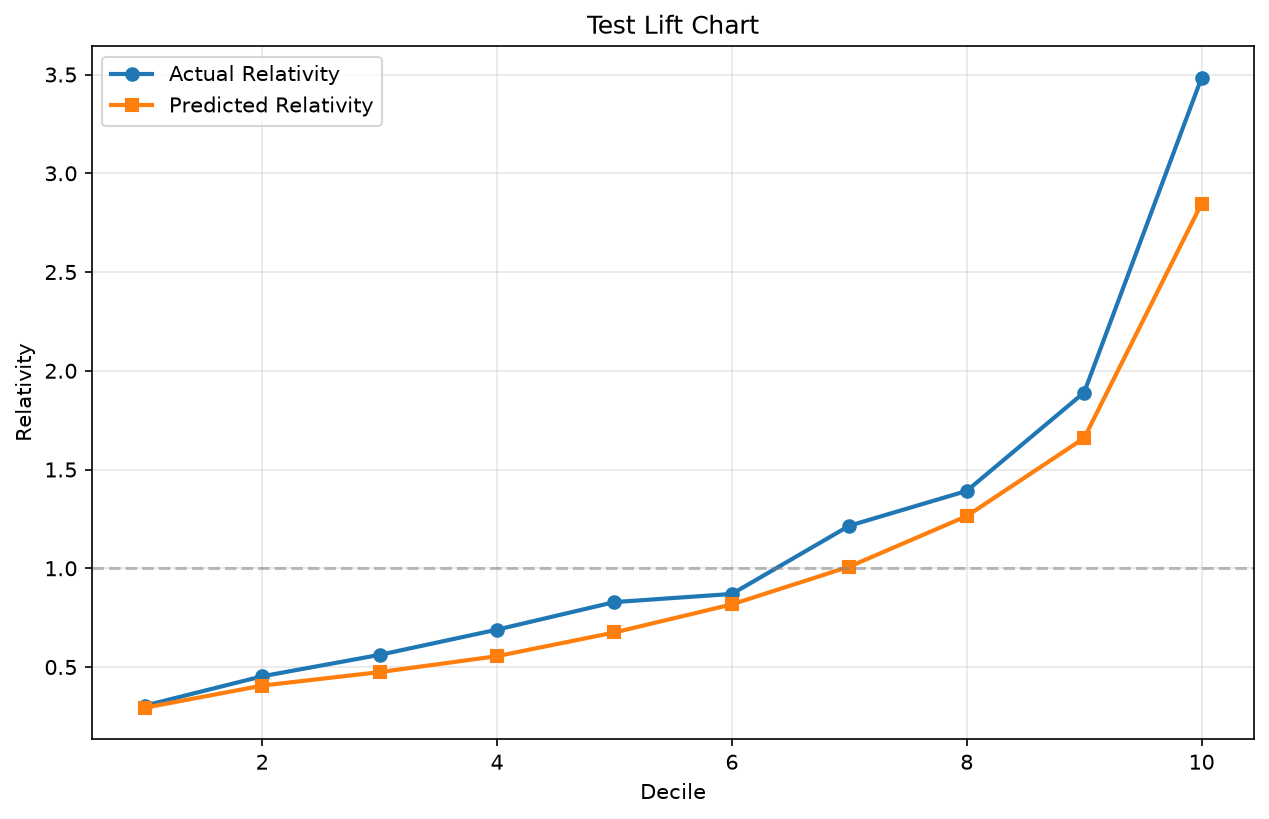


Test decile table:
   decile          act         pred   act_rel  pred_rel
0       1   133.287275   128.653575  0.304480  0.293895
1       2   198.382837   177.737863  0.453183  0.406022
2       3   245.839175   207.612616  0.561592  0.474268
3       4   301.777000   242.971075  0.689376  0.555040
4       5   362.827411   295.539623  0.828839  0.675127
5       6   380.884923   357.730593  0.870089  0.817196
6       7   532.076266   441.399889  1.215469  1.008329
7       8   609.274725   553.451004  1.391820  1.264297
8       9   827.371243   726.449160  1.890037  1.659492
9      10  1525.024882  1245.992170  3.483749  2.846330


In [20]:
# Test lift chart
print("\n* Generating test lift chart...")
fig_test_orig, table_test = create_lift_chart(test_orig, weight_col, bins=10, title="Test Lift Chart")

test_chart_file = f"{output_base}/results/05_lift_chart_test.png"
fig_test_orig.savefig(test_chart_file, dpi=150, bbox_inches='tight')
plt.close(fig_test_orig)

print(f"  Saved: {test_chart_file}")

# Display inline in notebook
display(Image(test_chart_file))

print("\nTest decile table:")
print(table_test[['decile', 'act', 'pred', 'act_rel', 'pred_rel']])

In [21]:
print("\n########################################")
print("# STAGE 05: COMPLETE")
print("########################################")


########################################
# STAGE 05: COMPLETE
########################################
